# Word2Vec 

"*Dime con quien andas y te diré quién eres*" - [Francisco de Quevedo en el siglo XVI](https://significalogia.com/dime-con-quien-andas-y-te-dire-quien-eres-significado-y-origen-de-este-refran/)
                                
*Word2Vec* es una técnica de **Procesamiento del Lenguaje Natural** (*NLP*) utilizada para representar palabras como vectores (en un **espacio continuo**) de características numéricas de baja dimensión. Este método, desarrollado por un equipo de Google dirigido por Tomas Mikolov en 2013, ha revolucionado la forma en que se representan las palabras en el espacio vectorial, permitiendo que las máquinas comprendan y procesen el texto de una manera más eficiente y efectiva.

*Word2Vec* utiliza dos arquitecturas principales para aprender las representaciones de las palabras:

1. **CBOW** (Continuous Bag of Words): Predice una palabra objetivo basada en su contexto circundante. Es decir, toma las palabras del contexto y trata de predecir la palabra central.
1. **Skip-gram**: Predice el contexto de una palabra objetivo. Toma una palabra central y trata de predecir las palabras circundantes en el contexto.

Ambos métodos se basan en redes neuronales simples y generan vectores de palabras que capturan las **relaciones semánticas** entre ellas.

El supuesto más importante de *Word2Vec* es que 2 palabras que tienen un **contexto similar**, entonces deben tener un **significado similar**, por ende, una representación vectorial similar.

Por ejemplo, palabras como "*perro*", "*cachorro*", "*mascota*" suelen estar en contextos similares, por ende su representación vectorial en *Word2Vec* debe ser similar. Es posible llegar a este tipo de conclusiones, gracias a que *Word2Vec* captura las relaciones semánticas entre palabras en base a los patrones descubiertos en la co-ocurrencia  de palabras dado un corpus.

# Load data

In [15]:
import itertools as it
from gensim.models.word2vec import LineSentence

In [2]:
trigram_sentences_filepath = r'..\..\..\data\ngrams\full-data\trigram_sentences_all.txt'

In [3]:
trigram_sentences = LineSentence(trigram_sentences_filepath)

Algunos mensajes preprocesados son:

In [18]:
for trigram_sentence in it.islice(trigram_sentences, 123, 128):
    print(' '.join(trigram_sentence))
    print('')

compartar conocimiento idea iniciativa proyecto mejorar vida america_latino_caribe silvicultura biodiversidad desarrollo agricola turismo ciudades sostenibles mitigacion frente cambio_climatico infraestructura energia desarrollo_sostenible mas suscribiendote blog bid sostenibilidad ciudad sostenible cambio_climatico politica salvaguardia ambiental transporte energia agua saneamiento mirar video youtube tema descarga publicacion suscribete curso banco interamericano desarrollo bid mejorar_calidad vida america_latino_caribe ayudar mejorar salud educacion infraestructura traves apoyo financiero tecnico pais reducir pobreza desigualdad objetivo alcanzar desarrollo_sostenible respetuoso clima

upecista 22 estudiante ciencia politica pais juan jose ramirez algarra dejar alto nombre unicesar competir estudiante universidad publica privado colombia continuo excelente actividad academico juan jose ramirez algarra estudiante 10deg semestre programa derecho universidad popular cesar codear estudi

# Word2Vec

## CBOW

In [4]:
import multiprocessing
from gensim.models import Word2Vec

In [5]:
cores = multiprocessing.cpu_count()
print(f"Number of cores available: {cores}")

Number of cores available: 16


Definir el modelo

In [ ]:
%%time
if 1 == 1:
    # Definir modelo
    w2v_model = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )
    # Construir vocabulario
    w2v_model.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )
    # Entrenar el modelo
    w2v_model.train(
        trigram_sentences, 
        total_examples=w2v_model.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model.save(r"..\..\models\w2v\w2v-cbow-full-data.model")
else:
    w2v_model = Word2Vec.load(r"..\..\models\w2v\w2v-cbow-full-data.model")

Comportamiento

In [24]:
similar_words = w2v_model.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatico: 0.5595445036888123
climatica: 0.46008628606796265
cambio_climatico: 0.4532386362552643
condicion_climatica: 0.3624676764011383
temperatura: 0.3457626700401306
climatologia: 0.3454887866973877
fenomeno_meteorologicos: 0.34138742089271545
calentamiento: 0.34075936675071716
aumento_temperatura: 0.3273131251335144
atmosferico: 0.3161963224411011


In [25]:
w2v_model.wv.most_similar(positive=["cambio"])

[('cambiar', 0.5129318833351135),
 ('transformacion', 0.463152676820755),
 ('alteracion', 0.4314107894897461),
 ('variacion', 0.4152984321117401),
 ('modificar', 0.38005852699279785),
 ('modificacion', 0.3701009154319763),
 ('calentamiento', 0.362532377243042),
 ('comportamiento', 0.3548702895641327),
 ('impacto', 0.3531821668148041),
 ('desequilibrio', 0.3282487690448761)]

In [26]:
w2v_model.wv.most_similar(positive=["cambio_climatico"])

[('calentamiento_global', 0.7242192029953003),
 ('crisis_climatico', 0.623238742351532),
 ('cambioclimatico', 0.5191892385482788),
 ('climatico', 0.4934885799884796),
 ('emergencia_climatico', 0.4595339596271515),
 ('clima', 0.4532386362552643),
 ('desertificacion', 0.4177307188510895),
 ('calentamiento', 0.41444817185401917),
 ('climatica', 0.40594255924224854),
 ('perdida_biodiversidad', 0.4022414982318878)]

In [27]:
w2v_model.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.7034354209899902),
 ('ambiente', 0.6702035665512085),
 ('proteccion_medio_ambiente', 0.48522233963012695),
 ('cuidado_medio_ambiente', 0.4353471100330353),
 ('ambiental', 0.4315119981765747),
 ('salud', 0.39361679553985596),
 ('recurso_natural', 0.38537532091140747),
 ('biodiversidad', 0.3787153959274292),
 ('naturaleza', 0.37795138359069824),
 ('medioambiental', 0.3589673340320587)]

In [28]:
w2v_model.wv.most_similar(positive=["agua"])

[('agua_dulce', 0.5891125202178955),
 ('agua_potable', 0.5739935040473938),
 ('acuifero', 0.4776276648044586),
 ('nutrient', 0.4535585343837738),
 ('rio', 0.435533732175827),
 ('liquido', 0.4337154030799866),
 ('suelo', 0.42226454615592957),
 ('recurso_hidrico', 0.4107363522052765),
 ('agua_residual', 0.3955221176147461),
 ('mar', 0.3806343078613281)]

In [29]:
w2v_model.wv.most_similar(positive=["sol"])

[('solar', 0.4024251103401184),
 ('luz', 0.3998667299747467),
 ('rayo', 0.39304932951927185),
 ('radiacion', 0.38443753123283386),
 ('estrella', 0.36954712867736816),
 ('calor', 0.3647654950618744),
 ('rayo_sol', 0.3622981905937195),
 ('luz_solar', 0.36205780506134033),
 ('campo_magnetico', 0.3614879548549652),
 ('cielo', 0.3412502408027649)]

In [30]:
w2v_model.wv.most_similar(positive=["desastre"])

[('catastrofe', 0.6100946664810181),
 ('catastrof', 0.5515577793121338),
 ('desastre_natural', 0.5104809999465942),
 ('tragedia', 0.46723613142967224),
 ('dano', 0.457133024930954),
 ('colapso', 0.4554784893989563),
 ('crisis', 0.43550434708595276),
 ('cataclismo', 0.41405946016311646),
 ('devastacion', 0.3963443636894226),
 ('pandemia', 0.3909819424152374)]

In [31]:
w2v_model.wv.most_similar(positive=["desastre_natural"])

[('desastre', 0.5104809403419495),
 ('catastrof', 0.45376941561698914),
 ('catastrof_natural', 0.433420866727829),
 ('fenomeno_natural', 0.4178577959537506),
 ('fenomeno', 0.40395745635032654),
 ('inundacion', 0.40005189180374146),
 ('fenomeno_meteorologico_extremo', 0.39416274428367615),
 ('sequia', 0.3908959925174713),
 ('pandemia', 0.3686412572860718),
 ('incendio', 0.3620809316635132)]

In [32]:
w2v_model.wv.most_similar(positive=["incremento"])

[('aumento', 0.8038116693496704),
 ('disminucion', 0.5614980459213257),
 ('aumentar', 0.5599395036697388),
 ('incrementar', 0.5513755083084106),
 ('reduccion', 0.5507983565330505),
 ('descenso', 0.4536835849285126),
 ('subida', 0.44712740182876587),
 ('aumento_temperatura', 0.42752644419670105),
 ('disminuir', 0.4203869104385376),
 ('creciente', 0.3968823552131653)]

In [33]:
w2v_model.wv.most_similar(positive=["temperatura"])

[('aumento_temperatura', 0.6493485569953918),
 ('calentamiento', 0.5493261218070984),
 ('alto_temperatura', 0.5368860960006714),
 ('incremento_temperatura', 0.5069370865821838),
 ('nivel_mar', 0.4953952431678772),
 ('calor', 0.4879480004310608),
 ('calido', 0.48320236802101135),
 ('precipitacion', 0.47271957993507385),
 ('calentar', 0.4477507770061493),
 ('ola_calor', 0.44072219729423523)]

In [34]:
w2v_model.wv.most_similar(positive=["bajar"])

[('subir', 0.5660752654075623),
 ('aumentar', 0.47122329473495483),
 ('disminuir', 0.4697307348251343),
 ('elevar', 0.4489991068840027),
 ('reducir', 0.44458305835723877),
 ('incrementar', 0.41204017400741577),
 ('disparar', 0.395354688167572),
 ('descender', 0.3876798450946808),
 ('rebajar', 0.37813854217529297),
 ('alto', 0.35134661197662354)]

In [52]:
w2v_model.wv.most_similar(positive=["mas"])

[('demasiado', 0.43521007895469666),
 ('extremadamente', 0.40986156463623047),
 ('suficientemente', 0.38953307271003723),
 ('relativamente', 0.36813798546791077),
 ('particularmente', 0.33426225185394287),
 ('cuan', 0.32840803265571594),
 ('mundo', 0.30340686440467834),
 ('probablemente', 0.2974410653114319),
 ('especialmente', 0.28252261877059937),
 ('vivir', 0.28017452359199524)]

In [53]:
w2v_model.wv.most_similar(positive=["gobierno"])

[('autoridad', 0.4794454276561737),
 ('administracion', 0.4689784348011017),
 ('presidente', 0.46488192677497864),
 ('ejecutivo', 0.4593389928340912),
 ('gobernante', 0.4381699562072754),
 ('mandatario', 0.4115612804889679),
 ('partido', 0.40742263197898865),
 ('politico', 0.4039086401462555),
 ('politica', 0.39100074768066406),
 ('president', 0.3762139081954956)]

Similitud entre 2 tokens:

In [35]:
w2v_model.wv.similarity("incrementar", "temperatura")

0.07944885

In [36]:
w2v_model.wv.similarity("disminuir", "temperatura")

0.1896066

## Skip Gram

In [39]:
%%time
if 1 == 1:
    w2v_model_sg = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )

    w2v_model_sg.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )

    w2v_model_sg.train(
        trigram_sentences, 
        total_examples=w2v_model_sg.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model_sg.save(r"..\..\models\w2v\w2v-sg-full-data.model")
else:
    w2v_model_sg = Word2Vec.load(r"..\..\models\w2v\w2v-sg-full-data.model")

CPU times: total: 57min 57s
Wall time: 4min 14s


(247847580, 308888280)

In [40]:
similar_words = w2v_model_sg.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatico: 0.5188308358192444
climatica: 0.42133450508117676
cambio_climatico: 0.40911632776260376
calentamiento: 0.30423998832702637
temperatura: 0.3039124608039856
condicion_climatica: 0.3026827573776245
climatologia: 0.2978074848651886
meteorologia: 0.29386791586875916
atmosferico: 0.29204368591308594
fenomeno_meteorologicos: 0.2737429738044739


In [41]:
w2v_model_sg.wv.most_similar(positive=["cambio"])

[('cambiar', 0.49337077140808105),
 ('transformacion', 0.38498610258102417),
 ('alteracion', 0.3431552052497864),
 ('modificar', 0.3419925272464752),
 ('drastico', 0.32691141963005066),
 ('radical', 0.3236880302429199),
 ('modificacion', 0.32027775049209595),
 ('variacion', 0.31624189019203186),
 ('abrupto', 0.29544180631637573),
 ('alterar', 0.28630292415618896)]

In [43]:
w2v_model_sg.wv.most_similar(positive=["cambio_climatico"])

[('calentamiento_global', 0.593559741973877),
 ('crisis_climatico', 0.4973621666431427),
 ('cambioclimatico', 0.47628918290138245),
 ('clima', 0.40911629796028137),
 ('climatico', 0.407939612865448),
 ('emergencia_climatico', 0.39149096608161926),
 ('calentamiento', 0.33937808871269226),
 ('calentamientoglobal', 0.3307618796825409),
 ('climatica', 0.3152428865432739),
 ('fenomeno', 0.30522462725639343)]

In [44]:
w2v_model_sg.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.5675256252288818),
 ('ambiente', 0.5043978691101074),
 ('cuidado_medio_ambiente', 0.3779172897338867),
 ('recurso_natural', 0.35474535822868347),
 ('biodiversidad', 0.3470262587070465),
 ('proteccion_medio_ambiente', 0.3440013527870178),
 ('ambiental', 0.3375729024410248),
 ('naturaleza', 0.32451382279396057),
 ('medioambiental', 0.31074535846710205),
 ('ecologia', 0.2966594696044922)]

In [45]:
w2v_model_sg.wv.most_similar(positive=["agua"])

[('agua_potable', 0.4898034632205963),
 ('agua_dulce', 0.48026546835899353),
 ('liquido', 0.42504027485847473),
 ('acuifero', 0.39538493752479553),
 ('rio', 0.38275885581970215),
 ('nutrient', 0.36209526658058167),
 ('mar', 0.36124947667121887),
 ('superficial', 0.3583206832408905),
 ('recurso_hidrico', 0.35378819704055786),
 ('oceano', 0.3514350950717926)]

In [49]:
w2v_model_sg.wv.most_similar(positive=["mas"])

[('demasiado', 0.39476296305656433),
 ('extremadamente', 0.385348916053772),
 ('relativamente', 0.3303438127040863),
 ('particularmente', 0.322005957365036),
 ('suficientemente', 0.31945666670799255),
 ('especialmente', 0.3034120798110962),
 ('cuan', 0.29353249073028564),
 ('adema', 0.290508896112442),
 ('ano', 0.2900882661342621),
 ('mundo', 0.2849713861942291)]

In [50]:
w2v_model_sg.wv.most_similar(positive=["ano"])

[('anos', 0.5478973388671875),
 ('mes', 0.5255283713340759),
 ('decada', 0.46987783908843994),
 ('periodo', 0.4111039340496063),
 ('anos_despues', 0.39477774500846863),
 ('enero', 0.3802248239517212),
 ('2020', 0.3777904808521271),
 ('semana', 0.37502652406692505),
 ('siglo', 0.37297123670578003),
 ('diciembre', 0.368043452501297)]

In [51]:
w2v_model_sg.wv.most_similar(positive=["gobierno"])

[('presidente', 0.4010256230831146),
 ('autoridad', 0.38820263743400574),
 ('gobernante', 0.3844029903411865),
 ('ejecutivo', 0.36839795112609863),
 ('administracion', 0.35582634806632996),
 ('gobernar', 0.35382646322250366),
 ('gubernamental', 0.3379681706428528),
 ('psoe', 0.3360668420791626),
 ('legislatura', 0.33202847838401794),
 ('oposicion', 0.3313787877559662)]

# T-SNE

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [47]:
words = ["agua", "clima", "medio_ambiente", "paris", "cambio_climatico", "falta", "nube", "peligro", "recurso", "acuerdo", "america", "unido", "ley", "temperatura", "frio", "calor"]
print(f"Numero de palabras {len(words)}")
word_vectors = [w2v_model_sg.wv[word] for word in words]
word_vectors = np.array(word_vectors)

Numero de palabras 16


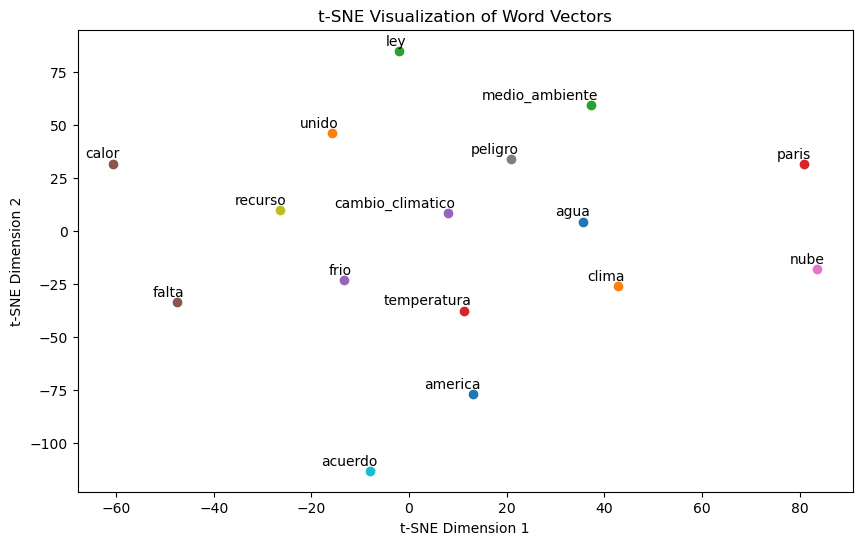

In [48]:
tsne_model = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_vectors = tsne_model.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(tsne_vectors[i, 0], tsne_vectors[i, 1])
    plt.annotate(word, xy=(tsne_vectors[i, 0], tsne_vectors[i, 1]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

plt.title('t-SNE Visualization of Word Vectors')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()